In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [183]:
class TruncatedMSE(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, noise_var, num_samples=1000, eps=1e-5):
        stacked = pred.unsqueeze(1).repeat(1, num_samples, 1)
        noise = (noise_var ** 0.5) * ch.randn_like(stacked)
        noised = stacked + noise

        mask = phi(noised).float()
        z = (mask * noised).sum(dim=1) / (mask.sum(dim=1) + eps)  
        P_hat = mask.mean(dim=1)  

        ctx.save_for_backward(targ, z, noise_var)
        quadratic_loss = -.5*(pred - targ).pow(2) / noise_var
        log_lambda_ = -.5*ch.log(1/noise_var)
        trunc_const = ch.log(P_hat + eps)

        return -(quadratic_loss - log_lambda_ - trunc_const) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        targ, z, noise_var = ctx.saved_tensors
        eps = 1e-8

        grad_pred = (targ - z) / noise_var
        return - grad_pred / targ.size(0), None, None, None, None, None

In [184]:
def trunc_mse(pred, targ, phi, noise_var, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    pred.requires_grad = True
    loss = TruncatedMSE.apply(pred, targ, phi, noise_var)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad

# One Dimensional Truncated Linear Regression

In [185]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(10000, 1)
NOISE_VAR = 3*ch.ones(1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.sqrt(NOISE_VAR)*ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 10000
W fit:
 [0.96562815]


In [186]:
def phi(X): 
    return X > 0
#     return ch.ones_like(X)

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.609
trunc lin reg W:
 [[2.457683]]


<IPython.core.display.Javascript object>


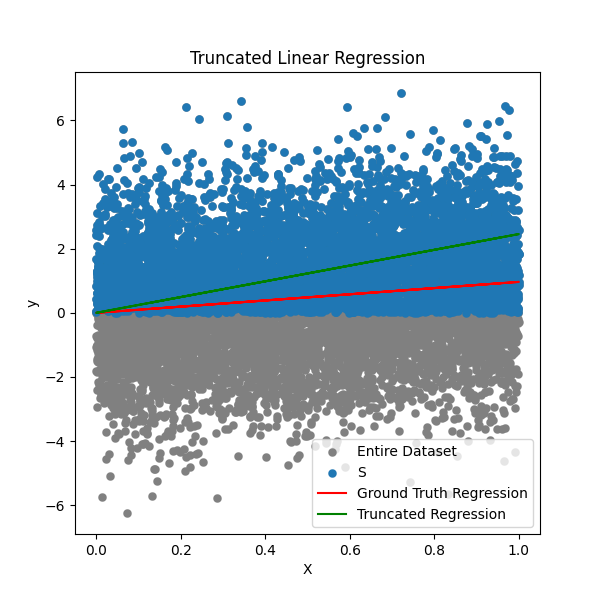

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [188]:
ws = ch.linspace(-1, 5, 50)

losses = ch.Tensor([])
grads = ch.Tensor([])

for w in ws: 
    loss, grad = trunc_mse(X_trunc @ w.reshape(1, 1), Y_trunc, phi, NOISE_VAR)
    losses = ch.cat([losses, loss[...,None].detach()])
    grads = ch.cat([grads, (grad * X_trunc).sum(0)])

<IPython.core.display.Javascript object>


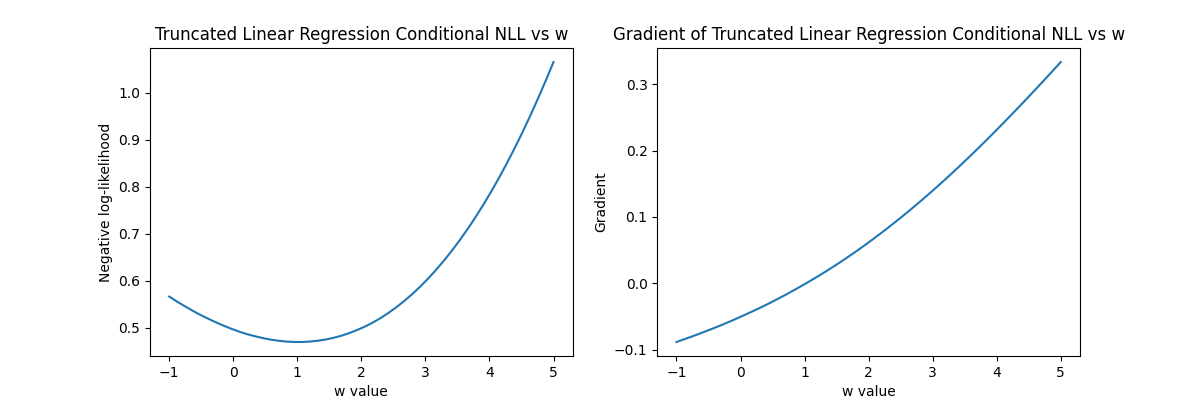

In [189]:
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses)
ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL vs w")

ax2.plot(ws, grads)
ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL vs w")

plt.show()

In [190]:
ws[grads.abs().argmin()], grads.abs().min()

(tensor(1.0816), tensor(0.0033))

In [191]:
ws[losses.argmin()], losses[losses.argmin()]

(tensor(0.9592), tensor([0.4702]))

In [192]:
trunc_mse(X_trunc @ ch.from_numpy(W_fit.reshape(1, 1)), Y_trunc, phi, NOISE_VAR)[0] * NOISE_VAR * 2

tensor([2.8213], grad_fn=<MulBackward0>)

In [193]:
from torch.nn import MSELoss
mse_loss = MSELoss()

mse_loss(X_trunc @ ch.from_numpy(W_fit.reshape(1, 1)), Y_trunc)

tensor(2.4921)

# One Dimensional Linear Regression with Bias

In [15]:
W = ch.ones(1)
W0 = ch.ones(1)
print(f'groud truth W:\n {W}')
print(f'ground truth bias:\n {W0}')
NOISE_VAR = 3*ch.ones(1,)

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + ch.sqrt(NOISE_VAR)*ch.randn(X.size(0))

gt_lin_reg = LinearRegression()
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_
W0_fit = gt_lin_reg.intercept_

print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([1.])
ground truth bias:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [0.9796675]
W0 fit:
 1.0053772926330566


In [16]:
def phi(X): 
    return X > 1

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.614
trunc lin reg W:
 [[0.36077398]]
trunc lin reg W0:
 [2.3967872]


<IPython.core.display.Javascript object>


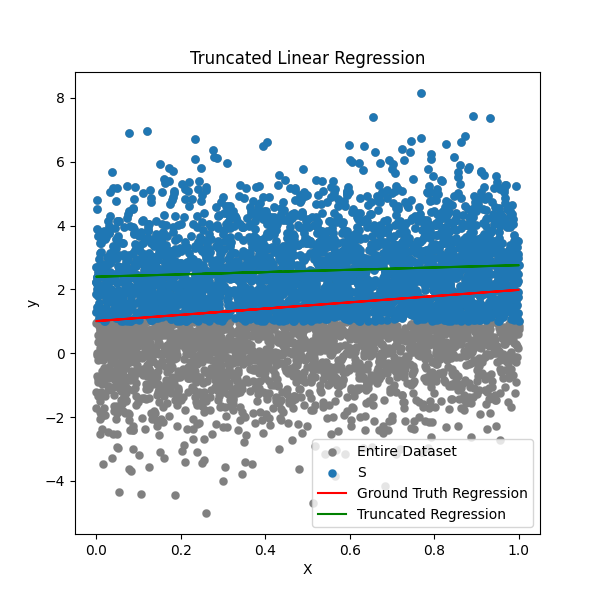

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [18]:
# === Parameter grids ===
W_values = ch.linspace(0, 2, 25)
W0_values = ch.linspace(0, 2, 25)
W_, W0_ = ch.meshgrid(W_values, W0_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc)], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_W0 = ch.zeros_like(W0_)
for i in range(len(W_values)):
    for j in range(len(W0_values)):
        trunc_pred = X_trunc_ones @ ch.cat([W_[i, j][None,...], W0_[i, j][None,...]])[...,None]
        loss, grad = trunc_mse(trunc_pred, Y_trunc, phi, NOISE_VAR)
    
        grad_ = (grad * X_trunc_ones).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]

/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_159395/3934080455.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  Z[i, j] = loss


Ground truth: w=0.980, w0=1.005
Minimum found: w=0.917, w0=1.000, loss=-0.066

Loss at ground truth: -0.066
Loss at minimum: -0.066
Difference: 0.000


<IPython.core.display.Javascript object>


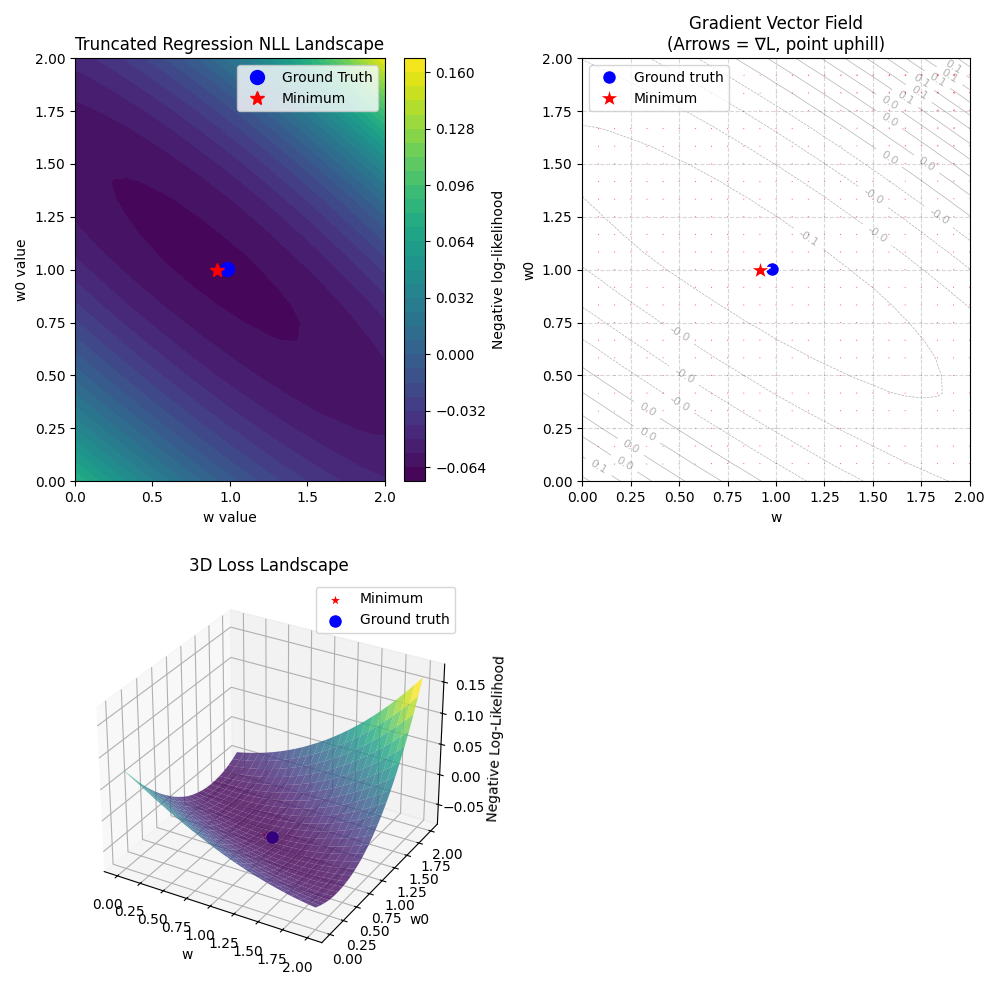

In [19]:
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_[min_idx], W0_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W_fit.item():.3f}, w0={W0_fit.item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse(X_trunc_ones @ ch.from_numpy(np.concatenate([W_fit, W0_fit.reshape(1,)]))[...,None], Y_trunc, phi, NOISE_VAR)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W_fit.item(), W0_fit.item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W_fit.item(), W0_fit.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('w0')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, W0_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [W0_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W_fit.item()], [W0_fit.item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('w0')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [20]:
W_min, W_fit

(tensor(0.9167), array([0.9796675], dtype=float32))

# Two Dimensional Truncated Linear Regression

In [21]:
W = ch.ones(2)
W0 = ch.ones(1)
NOISE_VAR = 3*ch.ones(1,)
print(f'groud truth W:\n {W}')

r1, r2 = 0, 1
X = (r1 - r2) * ch.rand(1000, 2) + r2
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + ch.sqrt(NOISE_VAR) * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

W_fit = ch.from_numpy(gt_lin_reg.coef_)
W0_fit = ch.from_numpy(gt_lin_reg.intercept_.reshape(1))

print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([1., 1.])
ground truth num samples: 1000
W fit:
 tensor([0.9367, 1.1455])
W0 fit:
 tensor([1.0566])


In [29]:
def phi(X): 
    return X > 2

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.506
trunc lin reg W:
 [[0.5639361  0.56325233]]
trunc lin reg W0:
 [2.9094872]


<IPython.core.display.Javascript object>


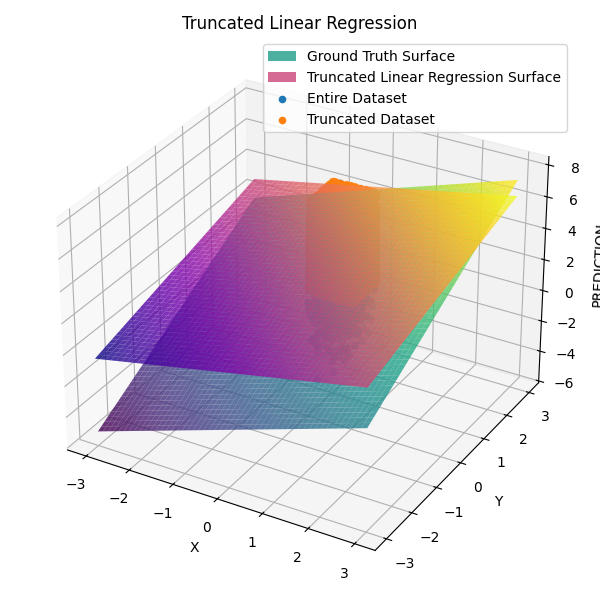

In [30]:
X_lin_space = ch.linspace(-3, 3, 50)
Y_lin_space = ch.linspace(-3, 3, 50)
X_, Y_ = meshgrid = ch.meshgrid(X_lin_space, Y_lin_space)

PRED = ch.zeros_like(X_)
TRUNC_PRED = ch.zeros_like(X_)
for i in range(len(X_)): 
    for j in range(len(Y_)): 
        x_ = ch.cat([X_[i, j][None,...], Y_[i, j][None,...]])[None,...]
        PRED[i, j] = ch.from_numpy(gt_lin_reg.predict(x_))
        TRUNC_PRED[i, j] = ch.from_numpy(trunc_lin_reg.predict(x_))
        
fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_subplot(111, projection='3d')
surf = ax1.plot_surface(X_, Y_, PRED, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Ground Truth Surface")
surf = ax1.plot_surface(X_, Y_, TRUNC_PRED, cmap='plasma', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Truncated Linear Regression Surface")
ax1.scatter(X[:,0], X[:,1], Y, label="Entire Dataset")
ax1.scatter(X_trunc[:,0], X_trunc[:,1], Y_trunc, label="Truncated Dataset")

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('PREDICTION')
ax1.set_title('Truncated Linear Regression')
ax1.legend()

plt.tight_layout()
plt.show()

In [33]:
# === Parameter grids ===
W1_values = ch.linspace(0, 2, 25)
W2_values = ch.linspace(0, 2, 25)
W1_, W2_ = ch.meshgrid(W1_values, W2_values)

X_trunc_ones = ch.cat([X_trunc, ch.ones_like(X_trunc[:,0][...,None])], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(W1_)
GRAD_W1 = ch.zeros_like(W1_)
GRAD_W2 = ch.zeros_like(W2_)
for i in range(len(W1_values)):
    for j in range(len(W2_values)):
        trunc_pred = X_trunc_ones @ ch.cat([W1_[i, j][None,...], W2_[i, j][None,...], W0_fit])[...,None]
        loss, grad = trunc_mse(trunc_pred, Y_trunc, phi, NOISE_VAR, 2500)
        grad_ = (grad * X_trunc_ones).sum(0)

        Z[i, j] = loss
        GRAD_W1[i, j] = grad_[0]
        GRAD_W2[i, j] = grad_[1]

Ground truth: w1=0.937, w2=1.145
Minimum found: w1=1.083, w2=1.167, loss=-0.146

Loss at ground truth: -0.142
Loss at minimum: -0.146
Difference: 0.005


<IPython.core.display.Javascript object>


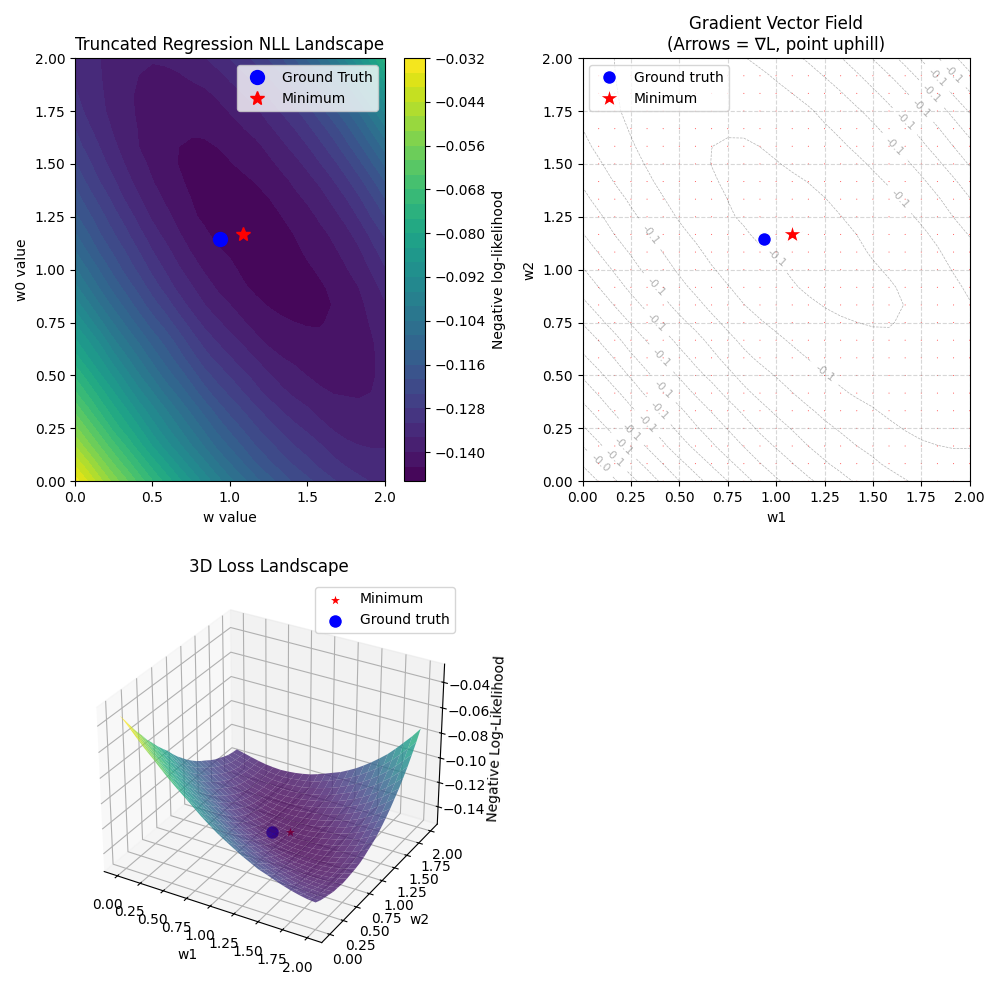

In [34]:
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W1_min, W2_min = W1_[min_idx], W2_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w1={W_fit[0].item():.3f}, w2={W_fit[1].item():.3f}")
print(f"Minimum found: w1={W1_min:.3f}, w2={W2_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc_ones @ ch.cat([W_fit, W0_fit]))[...,None], Y_trunc, phi, NOISE_VAR)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W1_, W2_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W_fit[0].item(), W_fit[1].item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W1_min.item(), W2_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W1_, W2_, GRAD_W1, GRAD_W2,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W1_, W2_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W_fit[0].item(), W_fit[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W1_min, W2_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W1_, W2_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W1_min], [W2_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([W_fit[0].item()], [W_fit[1].sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w1')
ax3.set_ylabel('w2')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

# Run Procedure - 1 Dimension No Intercept

In [35]:
W = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [1.0108652]


In [36]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.688
trunc lin reg W:
 [[1.6213145]]


In [37]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression(fit_intercept=False)
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(gt_norm.coef_.flatten())

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression(fit_intercept=False)
ols_trunc.fit(X_trunc, Y_trunc)
emp_ = ch.from_numpy(ols_trunc.coef_.flatten())
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

empirical weights: tensor([1.6213])
emp mse loss: 0.37264835834503174


In [49]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({
                    'lr': 1e-1,
                    'batch_size': 10,
                    'trials': 1,
                    'verbose': True
                        }) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha,
                                      noise_var=ch.ones(1, 1), 
                                        fit_intercept=False)
trunc_reg.fit(X_trunc, y_trunc_scale)

[2025-12-05 10:00:54] INFO - trial: 1
[2025-12-05 10:00:54] INFO - Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
[2025-12-05 10:00:54] INFO - [train] epoch=1 step=50 loss=0.0330 grad_norm=2.027e-02
[2025-12-05 10:00:54] INFO - [train] epoch=1 step=100 loss=0.0271 grad_norm=1.101e-01
[2025-12-05 10:00:54] INFO - [train] epoch=1 step=150 loss=0.0293 grad_norm=5.088e-02
[2025-12-05 10:00:54] INFO - [train] epoch=1 step=200 loss=0.0300 grad_norm=4.534e-02
[2025-12-05 10:00:54] INFO - [train] epoch=1 step=250 loss=0.0230 grad_norm=4.073e-02
[2025-12-05 10:00:54] INFO - [val] epoch=1 step=276 loss=0.0051 grad_norm=1.589e-01
[2025-12-05 10:00:54] INFO - [train] epoch=2 step=300 loss=0.0070 grad_norm=6.898e-02
[2025-12-05 10:00:54] INFO - [train] epoch=2 step=350 loss=0.0105 grad_norm=2.829e-01
[2025-12-05 10:00:54] INFO - [train] epoch=2 step=400 loss=0.0058 grad_norm=2.060e-01
[2025-1

TruncatedLinearRegression()

In [50]:
ws = ch.linspace(-1, 2, 20)

losses = [trunc_mse(X_trunc*w, Y_trunc, phi, ch.ones(1))[0].sum().detach() for w in ws]

<IPython.core.display.Javascript object>


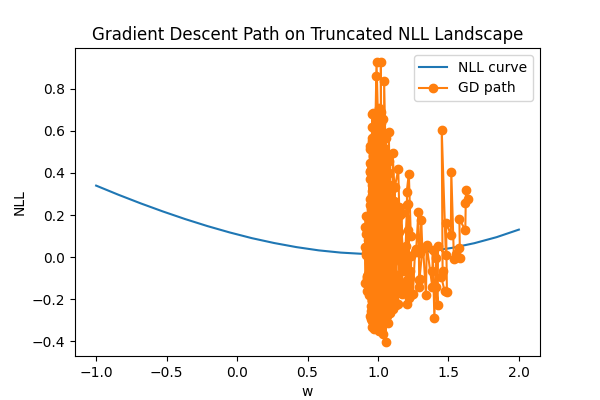

In [51]:
param_history = trunc_reg.trainer.train_param_history.detach()
loss_history = trunc_reg.trainer.train_losses.detach()

plt.figure(figsize=(6,4))
plt.plot(ws, losses, label="NLL curve")
plt.plot(param_history, loss_history, marker="o", label="GD path")
plt.xlabel("w")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

In [52]:
trunc_reg.trainer.train_param_history

tensor([[1.6189],
        [1.6368],
        [1.6244],
        ...,
        [1.0350],
        [1.0337],
        [1.0323]])

# Run Procedure - One Dimension with Intercept

In [63]:
W = ch.ones(1)
W0 = ch.ones(1)
NOISE_VAR = 1.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_
W0_fit = gt_lin_reg.intercept_
print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 5000
W fit:
 [1.009075]
W0 fit:
 1.0241749286651611


In [64]:
def phi(X): 
    return X > 1

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.692
trunc lin reg W:
 [[0.4877609]]
trunc lin reg W0:
 [1.7941315]


In [65]:
from torch.nn import MSELoss
mse_loss = MSELoss()

gt_norm = LinearRegression()
gt_norm.fit(X, Y)
gt_ = ch.from_numpy(np.concatenate([gt_norm.coef_.flatten(), gt_norm.intercept_.reshape(1,)]))

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression()
ols_trunc.fit(X_trunc, Y_trunc)
emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_.reshape(1,)]))
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

empirical weights: tensor([0.4878, 1.7941])
emp mse loss: 0.4323008060455322


In [77]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({
                    'lr': 2e-1,
                    'batch_size': 1,
                    'trials': 1,
                    'verbose': True, 
                    'gradient_steps': 2000
}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha,
                                      noise_var=ch.ones(1, 1))
trunc_reg.fit(X_trunc, y_trunc_scale)

[2025-12-05 10:05:53] INFO - trial: 1
[2025-12-05 10:05:53] INFO - Creating SGD optimizer: {'lr': 0.2, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=50 loss=0.2721 grad_norm=1.577e+00
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=100 loss=0.2016 grad_norm=9.127e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=150 loss=0.1250 grad_norm=5.331e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=200 loss=0.0575 grad_norm=7.543e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=250 loss=0.0542 grad_norm=3.758e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=300 loss=0.0332 grad_norm=3.725e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=350 loss=0.0269 grad_norm=3.982e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=400 loss=0.0366 grad_norm=8.017e-01
[2025-12-05 10:05:53] INFO - [train] epoch=1 step=450 loss=0.0456 grad_norm=5.046e-01
[2025

TruncatedLinearRegression()

Ground truth: w=1.000, w0=1.000
Minimum found: w=1.000, w0=1.000, loss=0.035

Loss at ground truth: 0.035
Loss at minimum: 0.035
Difference: 0.000


/tmp/ipykernel_159395/63657816.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z), Z.shape)


<IPython.core.display.Javascript object>


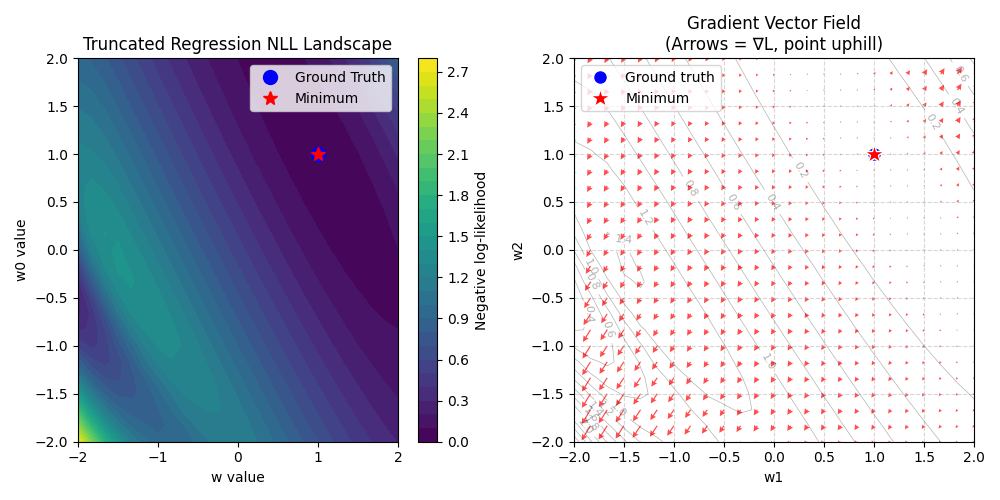

In [82]:
param_history = trunc_reg.trainer.train_param_history.detach()
loss_history = trunc_reg.trainer.train_losses.detach()

X_trunc_ones = ch.cat([X_trunc, ch.ones(X_trunc.size(0), 1)], dim=1)

W_ = ch.linspace(-2, 2, 25)
W0_ = ch.linspace(-2, 2, 25)
W_mesh, W0_mesh = ch.meshgrid(W_, W0_)

Z = ch.zeros_like(W_mesh)
GRAD_W = ch.zeros_like(W_mesh)
GRAD_W0 = ch.zeros_like(W_mesh)
for i in range(len(W_)): 
    for j in range(len(W0_)):
        
        loss, grad = trunc_mse(X_trunc*W_mesh[i, j] + W0_mesh[i, j], Y_trunc, phi, ch.ones(1))
        grad_ = (grad * X_trunc_ones).sum(0)
        Z[i, j] = loss.sum().detach()
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]
        
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_mesh[min_idx], W0_mesh[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={W.item():.3f}, w0={W0.item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc_ones @ ch.cat([W, W0]))[...,None], Y_trunc, phi, ch.ones(1))[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")
        
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(121)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(W.item(), W0.item(), 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(122)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(W.item(), W0.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)
       
    
plt.tight_layout()
plt.show()

# k Dimensions

In [178]:
k = 100

W = ch.ones(k, 1)
W0 = ch.ones(1, 1)
NOISE_VAR = 5.0
print(f'groud truth W:\n {W}')

X = ch.rand(10000, k)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + W0 + NOISE_VAR**.5 * ch.randn(X.size(0), 1)

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_
W0_fit = gt_lin_reg.intercept_
print(f'W fit:\n {W_fit}')
print(f'W0 fit:\n {W0_fit}')

groud truth W:
 tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
    

In [179]:
def phi(X): 
    return X > 50

trunc_indices = phi(Y).flatten().nonzero().flatten()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression()
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')
print(f'trunc lin reg W0:\n {trunc_lin_reg.intercept_}')

alpha:
 0.603
trunc lin reg W:
 [[0.61219573 0.7427411  0.6602235  0.7383814  0.68249893 0.5229783
  0.69640285 0.6074904  0.66723937 0.840793   0.6873008  0.57537854
  0.6612488  0.76789343 0.8142456  0.6226339  0.71580315 0.76814353
  0.56797194 0.6252221  0.6228318  0.6948293  0.6655616  0.5340047
  0.6265886  0.8464335  0.64921397 0.6956863  0.5038152  0.58214027
  0.5959737  0.72215533 0.7344831  0.55430365 0.66634727 0.6851373
  0.7396328  0.6805766  0.7497196  0.80569625 0.60120434 0.6519006
  0.63057244 0.8037149  0.69732225 0.6920768  0.68619126 0.7386183
  0.79792476 0.67681843 0.7301415  0.7438599  0.73473537 0.6774845
  0.6285633  0.62619317 0.7062923  0.6463067  0.684612   0.60822564
  0.6571388  0.6124938  0.652298   0.65341526 0.84004927 0.6585016
  0.6032069  0.6524229  0.7707287  0.56120145 0.58799255 0.6129403
  0.56744516 0.66846126 0.5644318  0.66572416 0.6245663  0.85210574
  0.66098565 0.6137521  0.69048107 0.55721295 0.6385889  0.62732077
  0.754568   0.69422203 

In [180]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

y_trunc_scale = Y_trunc / (NOISE_VAR ** .5)
# train algorithm
args = Parameters({
                    'lr': 1,
                    'batch_size': -1,
                    'trials': 1,
                    'verbose': True, 
                    'gradient_steps': 10, 
                    'optimizer': 'lbfgs'
}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi,
                                      alpha,
                                      noise_var=NOISE_VAR*ch.ones(1, 1))
trunc_reg.fit(X_trunc, Y_trunc)

[2025-12-05 10:18:12] INFO - trial: 1
[2025-12-05 10:18:12] INFO - Creating LBFGS optimizer: {'lr': 1.0, 'max_iter': 20, 'tolerance_grad': 1e-07, 'tolerance_change': 1e-09, 'history_size': 100, 'line_search_fn': 'strong_wolfe'}
[2025-12-05 10:18:12] INFO - [val] epoch=1 step=1 loss=0.2066 grad_norm=3.537e-03
[2025-12-05 10:18:13] INFO - [val] epoch=2 step=2 loss=0.2058 grad_norm=3.750e-03
[2025-12-05 10:18:14] INFO - [val] epoch=3 step=3 loss=0.2061 grad_norm=3.678e-03
[2025-12-05 10:18:14] INFO - [val] epoch=4 step=4 loss=0.2061 grad_norm=2.041e-03
[2025-12-05 10:18:14] INFO - [val] epoch=5 step=5 loss=0.2071 grad_norm=2.119e-03
[2025-12-05 10:18:15] INFO - [val] epoch=6 step=6 loss=0.1829 grad_norm=2.986e-03
[2025-12-05 10:18:16] INFO - [val] epoch=7 step=7 loss=0.1848 grad_norm=3.158e-03
[2025-12-05 10:18:16] INFO - [val] epoch=8 step=8 loss=0.1843 grad_norm=2.741e-03
[2025-12-05 10:18:17] INFO - [val] epoch=9 step=9 loss=0.1835 grad_norm=1.398e-03
[2025-12-05 10:18:17] INFO - [val]

TruncatedLinearRegression()

In [181]:
trunc_reg.best_coef_

tensor([0.8874, 0.8144, 0.9823, 1.1408, 1.0736, 0.5702, 0.8609, 0.7757, 0.9893,
        1.3742, 0.9866, 0.7693, 0.8486, 1.0499, 1.2086, 0.8703, 1.0314, 1.1830,
        0.8775, 1.0071, 0.8237, 1.0983, 0.9233, 0.5257, 0.8153, 1.5293, 0.6510,
        1.0567, 0.6105, 0.6778, 0.8744, 1.0302, 1.1710, 0.6728, 0.9511, 1.0820,
        1.1636, 1.1771, 1.1819, 1.2898, 0.7634, 0.9665, 0.8074, 1.1535, 1.0653,
        1.1528, 0.9229, 1.0674, 1.1849, 1.0607, 0.8875, 0.9731, 0.8782, 0.8570,
        0.9129, 0.9407, 0.8903, 0.8399, 1.1014, 0.7722, 1.0599, 0.7383, 0.8601,
        1.1079, 1.3066, 0.8425, 0.7058, 0.9190, 1.1386, 0.6870, 0.9245, 0.9969,
        0.7884, 0.8836, 0.6715, 0.9707, 1.0286, 1.3183, 0.8599, 0.8250, 0.9717,
        0.7395, 0.9048, 0.9385, 0.9953, 0.8301, 1.0422, 0.9849, 0.6946, 1.1598,
        1.1610, 0.9204, 0.9059, 1.0257, 1.1279, 0.9562, 1.1003, 0.9844, 0.7047,
        1.0102])

In [182]:
trunc_reg.best_intercept_

tensor(3.3671)

In [160]:
X_trunc.size()

torch.Size([5051, 20])

In [102]:
X @ W.T

tensor([[0.3344, 0.3344, 0.3344,  ..., 0.3344, 0.3344, 0.3344],
        [0.7139, 0.7139, 0.7139,  ..., 0.7139, 0.7139, 0.7139],
        [0.9179, 0.9179, 0.9179,  ..., 0.9179, 0.9179, 0.9179],
        ...,
        [0.7951, 0.7951, 0.7951,  ..., 0.7951, 0.7951, 0.7951],
        [0.7557, 0.7557, 0.7557,  ..., 0.7557, 0.7557, 0.7557],
        [0.8885, 0.8885, 0.8885,  ..., 0.8885, 0.8885, 0.8885]])